# OLIM 2.0 null-scenario simulation

This notebook is the readable simulation and diagnostic interface for the matched `null` scenario. Scientific behavior is imported from `opinion_model.shared` and `opinion_model.scenarios.null`; the notebook does not contain a second model implementation.

**Scenario boundary:** opinion-leader mechanisms are absent, platform mechanisms are absent, message availability is limited to followed producers, and the directed network remains fixed.

## 1. Purpose and evidentiary boundary

The null scenario establishes the behavior of the shared Beta-belief and communication model without either focal mechanism family. It is one control cell in the OLIM 2.0 two-by-two comparison. The current values are transparent exploratory assumptions rather than calibrated empirical estimates. Successful execution verifies the implementation and exposes its dynamics; it does not validate the model against observed behavior.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src" / "opinion_model").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from opinion_model.scenarios.null import (
    SHARED_FRAMEWORK_SOURCE_REVISION,
    FixedNullInitializer,
    assemble_null_components,
    final_condition_metrics,
    load_null_experiment_config,
    null_diagnostic_frames,
    run_null_condition,
    run_null_experiment,
    summarize_final_conditions,
)
from opinion_model.shared import DEFAULT_COMPONENTS

## 2. Resolved parameters and mechanism boundary

In [2]:
EXPERIMENT = load_null_experiment_config(PROJECT_ROOT / "configs" / "null.toml")
SIMULATION = EXPERIMENT.null.simulation
INITIALIZATION = EXPERIMENT.null.initialization

parameter_audit = pd.DataFrame(
    [
        ("experiment", "id", EXPERIMENT.experiment_id),
        ("experiment", "status", EXPERIMENT.status),
        ("experiment", "seeds", list(EXPERIMENT.seeds)),
        ("experiment", "extremism threshold", EXPERIMENT.extremism_threshold),
        ("simulation", "agents", SIMULATION.agent_count),
        ("simulation", "rounds", SIMULATION.rounds),
        ("simulation", "base origination probability", SIMULATION.base_origination_probability),
        ("simulation", "evidence weight", SIMULATION.evidence_weight),
        ("simulation", "consumption capacity", SIMULATION.consumption_capacity),
        ("simulation", "self-exposure", "excluded"),
        ("initialization", "network", f"directed Barabasi-Albert, m={INITIALIZATION.network_m}"),
        ("initialization", "ordinary mean distribution", f"Beta({INITIALIZATION.ordinary_mean_alpha:g}, {INITIALIZATION.ordinary_mean_alpha:g})"),
        ("initialization", "ordinary concentration", INITIALIZATION.ordinary_concentration),
        ("opinion leader", "mechanisms", "absent"),
        ("platform", "mechanisms", "absent"),
        ("network", "update", "static"),
        ("provenance", "shared framework source", SHARED_FRAMEWORK_SOURCE_REVISION),
    ],
    columns=["model part", "parameter", "resolved value"],
)
display(parameter_audit)

,model part,parameter,resolved value
0,experiment,id,null
1,experiment,status,exploratory
2,experiment,seeds,"[20260910, 20260911, 20260912, 20260913, 20260..."
3,experiment,extremism threshold,0.8
4,simulation,agents,500
5,simulation,rounds,50
6,simulation,base origination probability,0.1
7,simulation,evidence weight,0.1
8,simulation,consumption capacity,10
9,simulation,self-exposure,excluded


## 3. One matched run and component register

Seed `20260910` is inspected first. The initializer uses the same topology, edge-direction, and ordinary-belief random streams as the integrated baseline, but it stops before leader assignment or leader-belief replacement.

In [3]:
FIRST_SEED = EXPERIMENT.seeds[0]
FIRST_CONFIG = replace(
    EXPERIMENT.null,
    simulation=replace(EXPERIMENT.null.simulation, seed=FIRST_SEED),
)
FIRST_RUN = run_null_condition(
    FIRST_CONFIG,
    extremism_threshold=EXPERIMENT.extremism_threshold,
)
COMPONENTS = assemble_null_components(
    FIRST_CONFIG,
    initializer=FixedNullInitializer(FIRST_RUN.initialization.state),
)
component_register = pd.DataFrame(
    [
        {
            "component": name,
            "implementation": getattr(COMPONENTS, name).__name__ if hasattr(getattr(COMPONENTS, name), "__name__") else type(getattr(COMPONENTS, name)).__name__,
            "shared ordinary rule": getattr(COMPONENTS, name) is getattr(DEFAULT_COMPONENTS, name),
        }
        for name in (
            "message_origination",
            "message_selection",
            "message_aggregation",
            "opinion_update",
            "network_update",
        )
    ]
)
display(component_register)

,component,implementation,shared ordinary rule
0,message_origination,originate_message,True
1,message_selection,select_messages,True
2,message_aggregation,aggregate_messages,True
3,opinion_update,propose_opinion_update,True
4,network_update,propose_static_network,True


## 4. Close reading: rounds 1-5

The complete diagnostic tables remain available in `DIAGNOSTIC_FRAMES`. The displayed focal agents are selected transparently from the round-zero network: the two highest in-degree nodes and one median in-degree node. They are ordinary agents in `null`, even if the matched integrated scenario later assigns some of the same IDs an opinion-leader role.

In [4]:
DIAGNOSTIC_FRAMES = null_diagnostic_frames(
    FIRST_RUN.simulation_result,
    last_round=5,
)
TRANSITION_LEDGER = DIAGNOSTIC_FRAMES["transitions"]
round_audit = FIRST_RUN.round_metrics.loc[
    FIRST_RUN.round_metrics["round"] <= 5,
    [
        "round",
        "message_count",
        "exposure_count",
        "mean_signed_belief",
        "mean_absolute_belief",
        "edge_count",
        "homophily_ratio",
    ],
]

state0 = FIRST_RUN.initialization.state
in_degree = {agent_id: 0 for agent_id in state0.agents}
for producer_ids in state0.network.neighbors_by_agent.values():
    for producer_id in producer_ids:
        in_degree[producer_id] += 1
ranked = sorted(in_degree, key=lambda agent_id: (-in_degree[agent_id], agent_id))
median_ranked = sorted(in_degree, key=lambda agent_id: (in_degree[agent_id], agent_id))
FOCAL_AGENT_IDS = tuple(dict.fromkeys([ranked[0], ranked[1], median_ranked[len(median_ranked) // 2]]))
focal_register = pd.DataFrame(
    [{"agent_id": agent_id, "round-zero in-degree": in_degree[agent_id]} for agent_id in FOCAL_AGENT_IDS]
)

display(round_audit.round(6))
display(focal_register)
display(
    TRANSITION_LEDGER.loc[TRANSITION_LEDGER["agent_id"].isin(FOCAL_AGENT_IDS)].round(6)
)

,round,message_count,exposure_count,mean_signed_belief,mean_absolute_belief,edge_count,homophily_ratio
0,0,0,0,0.026410,0.387569,1491,0.501677
1,1,44,132,0.026441,0.385743,1491,0.502347
2,2,60,163,0.026099,0.381528,1491,0.504359
3,3,54,196,0.029804,0.378082,1491,0.504359
4,4,48,116,0.029985,0.375893,1491,0.502347
5,5,51,121,0.029438,0.374385,1491,0.502347


,agent_id,round-zero in-degree
0,4,48
1,0,23
2,383,2


,round,agent_id,a_before,b_before,origination_probability,p_support_at_origination,did_originate,originated_stance,received_message_count,n_support,n_oppose,weighted_support,weighted_oppose,a_after,b_after,signed_mean_before,signed_mean_after
0,1,0,2.234959,1.765041,0.1,0.603125,False,NaN,1,0,1,0.0,0.1,2.234959,1.865041,0.117479,0.090224
4,1,4,3.105874,0.894126,0.1,0.900406,False,NaN,3,2,1,0.2,0.1,3.305874,0.994126,0.552937,0.537616
383,1,383,3.519574,0.480426,0.1,0.969090,False,NaN,0,0,0,0.0,0.0,3.519574,0.480426,0.759787,0.759787
500,2,0,2.234959,1.865041,0.1,0.580284,False,NaN,2,1,1,0.1,0.1,2.334959,1.965041,0.090224,0.086027
504,2,4,3.305874,0.994126,0.1,0.899725,False,NaN,8,4,4,0.4,0.4,3.705874,1.394126,0.537616,0.453284
883,2,383,3.519574,0.480426,0.1,0.969090,False,NaN,0,0,0,0.0,0.0,3.519574,0.480426,0.759787,0.759787
1000,3,0,2.334959,1.965041,0.1,0.578046,False,NaN,3,2,1,0.2,0.1,2.534959,2.065041,0.086027,0.102156
1004,3,4,3.705874,1.394126,0.1,0.873063,False,NaN,7,2,5,0.2,0.5,3.905874,1.894126,0.453284,0.346853
1383,3,383,3.519574,0.480426,0.1,0.969090,False,NaN,0,0,0,0.0,0.0,3.519574,0.480426,0.759787,0.759787
1500,4,0,2.534959,2.065041,0.1,0.594983,False,NaN,0,0,0,0.0,0.0,2.534959,2.065041,0.102156,0.102156


## 5. Full 50-round trajectory for the inspected seed

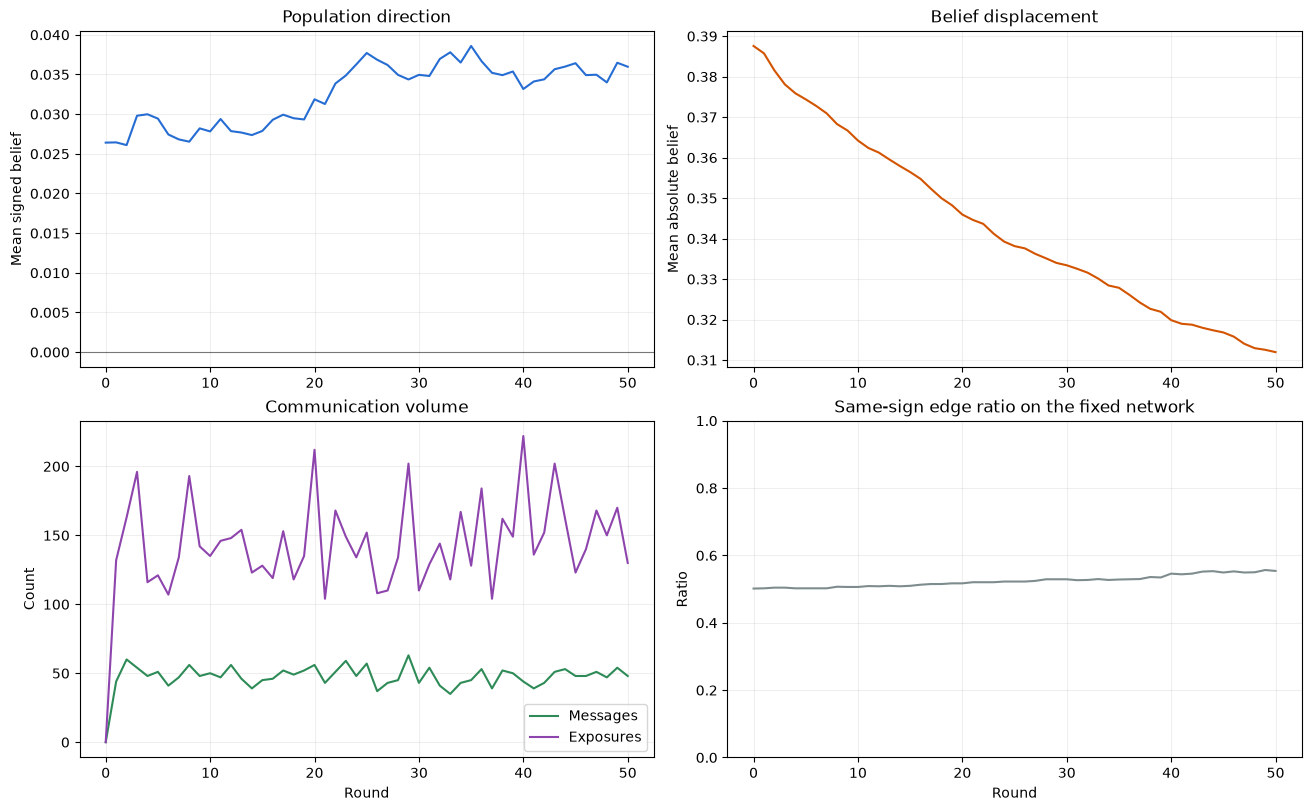

In [5]:
first_metrics = FIRST_RUN.round_metrics
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes[0, 0].plot(first_metrics["round"], first_metrics["mean_signed_belief"], color="#266dd3")
axes[0, 0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0, 0].set(title="Population direction", ylabel="Mean signed belief")
axes[0, 1].plot(first_metrics["round"], first_metrics["mean_absolute_belief"], color="#d35400")
axes[0, 1].set(title="Belief displacement", ylabel="Mean absolute belief")
axes[1, 0].plot(first_metrics["round"], first_metrics["message_count"], label="Messages", color="#2e8b57")
axes[1, 0].plot(first_metrics["round"], first_metrics["exposure_count"], label="Exposures", color="#8e44ad")
axes[1, 0].set(title="Communication volume", ylabel="Count", xlabel="Round")
axes[1, 0].legend()
axes[1, 1].plot(first_metrics["round"], first_metrics["homophily_ratio"], color="#7f8c8d")
axes[1, 1].set(title="Same-sign edge ratio on the fixed network", ylabel="Ratio", xlabel="Round", ylim=(0, 1))
for axis in axes.flat:
    axis.grid(alpha=0.2)
plt.show()

## 6. Ten-seed exploratory experiment

Each seed contributes one null run. The control is not duplicated under opinion-leader orientation labels because orientation has no meaning when opinion leaders are absent.

In [6]:
ROUND_METRICS = run_null_experiment(EXPERIMENT)
FINAL_METRICS = final_condition_metrics(ROUND_METRICS)
FINAL_SUMMARY = summarize_final_conditions(FINAL_METRICS)
display(FINAL_METRICS.round(6))
display(FINAL_SUMMARY.round(6))

,seed,condition,round,message_count,exposure_count,round_content_balance,cumulative_content_balance,mean_signed_belief,mean_absolute_belief,extremist_ratio,edge_count,mean_following_degree,homophily_ratio
0,20260910,null,50,48,130,-0.083333,0.058824,0.035980,0.311963,0.010,1491,2.982,0.553991
1,20260911,null,50,53,157,-0.056604,-0.059055,-0.047693,0.316902,0.024,1491,2.982,0.567404
2,20260912,null,50,48,197,0.083333,-0.021624,-0.014296,0.293858,0.014,1491,2.982,0.528504
3,20260913,null,50,48,140,-0.041667,-0.043693,-0.014641,0.288244,0.014,1491,2.982,0.551979
4,20260914,null,50,54,151,0.148148,-0.016543,-0.002550,0.292424,0.016,1491,2.982,0.544601
5,20260915,null,50,52,147,-0.076923,-0.036107,-0.033340,0.303282,0.016,1491,2.982,0.529846
6,20260916,null,50,53,155,-0.056604,0.009218,0.006182,0.317520,0.014,1491,2.982,0.562039
7,20260917,null,50,49,162,-0.061224,0.055870,0.045318,0.306158,0.014,1491,2.982,0.568746
8,20260918,null,50,47,90,-0.021277,-0.051628,-0.039131,0.290183,0.018,1491,2.982,0.539906
9,20260919,null,50,43,150,-0.069767,-0.061688,-0.031280,0.307092,0.016,1491,2.982,0.536553


,condition,run_count,mean_signed_belief_mean,mean_signed_belief_std,mean_absolute_belief_mean,mean_absolute_belief_std,extremist_ratio_mean,extremist_ratio_std,cumulative_content_balance_mean,cumulative_content_balance_std,edge_count_mean,edge_count_std,mean_following_degree_mean,mean_following_degree_std,homophily_ratio_mean,homophily_ratio_std
0,null,10,-0.009545,0.031263,0.302763,0.010995,0.0156,0.003627,-0.016643,0.044484,1491.0,0.0,2.982,0.0,0.548357,0.014803


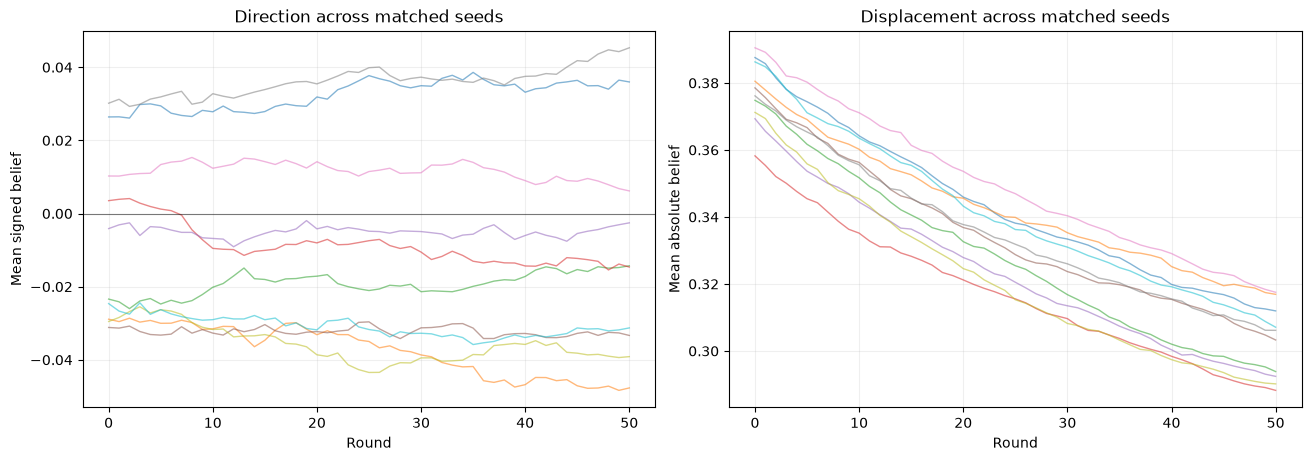

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for seed, frame in ROUND_METRICS.groupby("seed"):
    axes[0].plot(frame["round"], frame["mean_signed_belief"], alpha=0.55, linewidth=1, label=str(seed))
    axes[1].plot(frame["round"], frame["mean_absolute_belief"], alpha=0.55, linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set(title="Direction across matched seeds", xlabel="Round", ylabel="Mean signed belief")
axes[1].set(title="Displacement across matched seeds", xlabel="Round", ylabel="Mean absolute belief")
for axis in axes:
    axis.grid(alpha=0.2)
plt.show()

## 7. Executable null-boundary checks

In [8]:
initial_edges = set(
    DIAGNOSTIC_FRAMES["network"].query("round == 0")[["consumer_id", "producer_id"]].itertuples(index=False, name=None)
)
for round_index, frame in DIAGNOSTIC_FRAMES["network"].groupby("round"):
    observed_edges = set(frame[["consumer_id", "producer_id"]].itertuples(index=False, name=None))
    assert observed_edges == initial_edges, f"network changed in round {round_index}"

exposure_pairs = DIAGNOSTIC_FRAMES["exposures"][["consumer_id", "producer_id"]].itertuples(index=False, name=None)
assert all(pair in initial_edges and pair[0] != pair[1] for pair in exposure_pairs)
assert np.allclose(TRANSITION_LEDGER["a_after"], TRANSITION_LEDGER["a_before"] + TRANSITION_LEDGER["weighted_support"])
assert np.allclose(TRANSITION_LEDGER["b_after"], TRANSITION_LEDGER["b_before"] + TRANSITION_LEDGER["weighted_oppose"])
assert DIAGNOSTIC_FRAMES["origination"]["origination_probability"].eq(SIMULATION.base_origination_probability).all()
assert FIRST_RUN.round_metrics["edge_count"].nunique() == 1
assert set(ROUND_METRICS["condition"]) == {"null"}
assert ROUND_METRICS.groupby("seed").size().eq(SIMULATION.rounds + 1).all()

verification = pd.DataFrame(
    [
        ("Static network", True),
        ("Tied-source-only exposure", True),
        ("No self-exposure", True),
        ("Exact Beta transition reconstruction", True),
        ("Common origination probability", True),
        ("One null run per seed", True),
    ],
    columns=["check", "passed"],
)
display(verification)

,check,passed
0,Static network,True
1,Tied-source-only exposure,True
2,No self-exposure,True
3,Exact Beta transition reconstruction,True
4,Common origination probability,True
5,One null run per seed,True


## Interpretation boundary

The tables and plots describe the exploratory null model under the recorded assumptions. They do not by themselves establish empirical validity or estimate an opinion-leader or platform effect. Those claims require matched contrasts with the corresponding scenario branches after their shared framework and measurement definitions have been aligned.